In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle (2).json to kaggle (2).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d puneet6060/intel-image-classification
!unzip -q intel-image-classification.zip -d intel_data

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:22<00:00, 16.3MB/s]



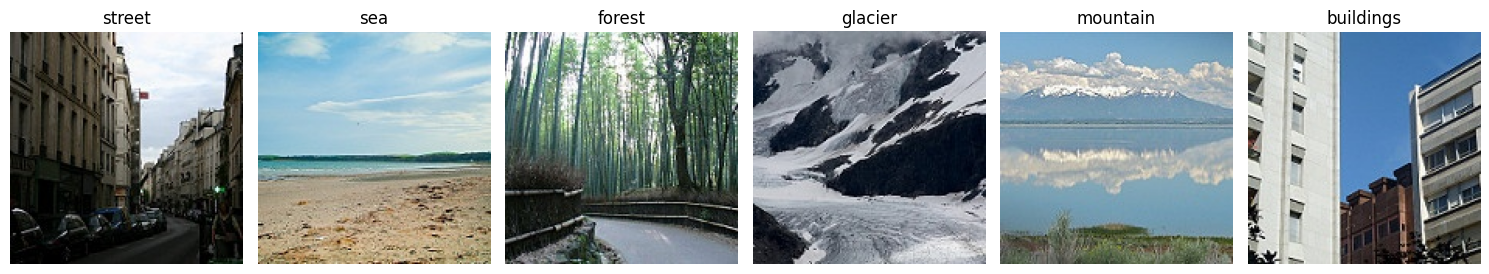

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


base_dir = 'intel_data/seg_train/seg_train'

categories = os.listdir(base_dir)

plt.figure(figsize=(15, 5))

for i, category in enumerate(categories):
    category_path = os.path.join(base_dir, category)

    random_image = random.choice(os.listdir(category_path))
    image_path = os.path.join(category_path, random_image)

    img = Image.open(image_path)

    plt.subplot(1,6 , i + 1)
    plt.imshow(img)
    plt.title(category, fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

--- حجم بيانات التدريب ---
    Category  Count
0     street   2382
1        sea   2274
2     forest   2271
3    glacier   2404
4   mountain   2512
5  buildings   2191

إجمالي صور التدريب: 14034


/tmp/ipykernel_478/1274318932.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Count', data=train_counts, palette='viridis')


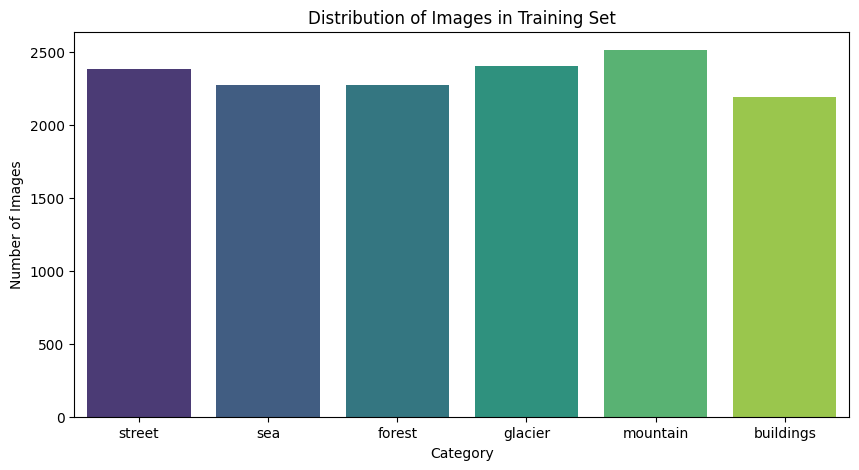

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TRAIN_DIR = 'intel_data/seg_train/seg_train'
TEST_DIR = 'intel_data/seg_test/seg_test'

def get_data_count(directory):
    data = []
    for category in os.listdir(directory):
        category_path = os.path.join(directory, category)
        if os.path.isdir(category_path):
            count = len(os.listdir(category_path))
            data.append({'Category': category, 'Count': count})
    return pd.DataFrame(data)

train_counts = get_data_count(TRAIN_DIR)
test_counts = get_data_count(TEST_DIR)

print("--- حجم بيانات التدريب ---")
print(train_counts)
print("\nإجمالي صور التدريب:", train_counts['Count'].sum())

plt.figure(figsize=(10, 5))
sns.barplot(x='Category', y='Count', data=train_counts, palette='viridis')
plt.title('Distribution of Images in Training Set')
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)


In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 32
IMAGE_SIZE = (150, 150)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 11230 images belonging to 6 classes.


In [ ]:
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [ ]:
base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')

base_model.trainable = False
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(6, activation='softmax')
])

/tmp/ipykernel_478/2233509598.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)
]

In [ ]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=callbacks
)
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n Acc:{test_acc * 100:.2f}%")

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 129s 314ms/step - accuracy: 0.7880 - loss: 0.5703 - val_accuracy: 0.8538 - val_loss: 0.3984 - learning_rate: 0.0010
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 83s 236ms/step - accuracy: 0.8392 - loss: 0.4339 - val_accuracy: 0.8695 - val_loss: 0.3665 - learning_rate: 0.0010
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 86s 244ms/step - accuracy: 0.8500 - loss: 0.4060 - val_accuracy: 0.8613 - val_loss: 0.3718 - learning_rate: 0.0010
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 83s 236ms/step - accuracy: 0.8584 - loss: 0.3928 - val_accuracy: 0.8684 - val_loss: 0.3479 - learning_rate: 0.0010
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 240ms/step - accuracy: 0.8549 - loss: 0.3879 - val_accuracy: 0.8727 - val_loss: 0.3442 - learning_rate: 0.0010
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 240ms/step - accuracy: 0.8614 - loss: 0.3779 - val_accuracy: 0.8766 - val_loss: 0.3449 - learning_rate: 0.0010
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 83s 237ms/step - accuracy: 0.

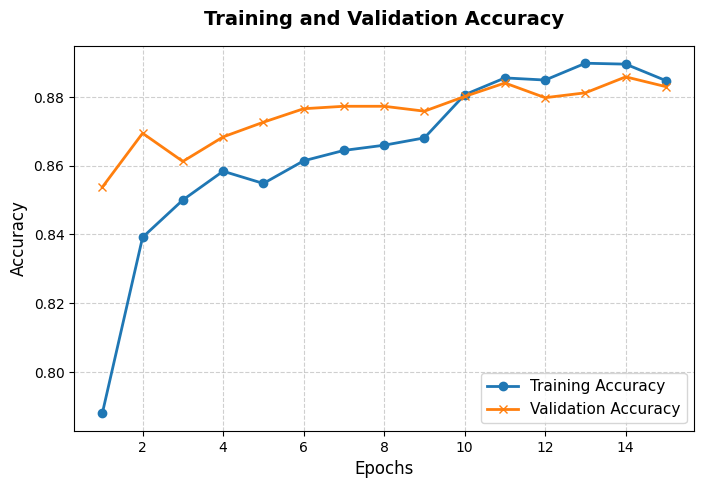

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs_range, acc, label='Training Accuracy', marker='o', linewidth=2, color='#1f77b4')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x', linewidth=2, color='#ff7f0e')

plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [ ]:
model.save_weights('intel_scene_weights.weights.h5')
model.save('intel_scene_model.h5')
files.download('intel_scene_weights.weights.h5')
files.download('intel_scene_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>